# 2. 벡터의 확장 개념

## 선형결합으로 만들 수 있는 공간

- **배울 것**: 선형결합, 생성공간(span), 선형독립, 기저와 좌표.
- 선형결합은 벡터마다 가중치를 곱한 뒤 더하는 것입니다. 재료 벡터와 가중치가 각각 방향과 사용량을 담당합니다.

$$
\mathbf y=\alpha_1\mathbf v_1+\cdots+\alpha_k\mathbf v_k
=V\boldsymbol\alpha
$$

- 코드의 $\mathbf v_1=(4,5,1)$, $\mathbf v_2=(-4,0,-4)$, $\mathbf v_3=(1,3,2)$에 가중치 $(1,2,-3)$을 적용하면 $(-7,-4,-13)$입니다.
- `zip(scalars, vectors)`는 같은 위치의 가중치와 벡터를 묶습니다. 두 목록의 길이가 다르면 짧은 쪽까지만 진행합니다.

## 직선, 평면, 그리고 선형독립

$$
\operatorname{span}(\mathbf v_1,\ldots,\mathbf v_k)
=\left\{\sum_i\alpha_i\mathbf v_i:\alpha_i\in\mathbb R\right\}
$$

- 영벡터가 아닌 벡터 하나의 배수들은 원점을 지나는 직선을 만듭니다.
- 3차원에서 서로 배수가 아닌 벡터 두 개는 원점을 지나는 평면을 만듭니다. 두 번째 벡터가 첫 번째의 배수라면 여전히 직선입니다.
- 난수 가중치로 찍은 점들은 생성공간의 일부만 보여 줍니다. 유한한 산점도 자체가 무한한 공간 전체는 아닙니다.
- $\sum_i\alpha_i\mathbf v_i=0$의 해가 모든 $\alpha_i=0$뿐이면 선형독립입니다. 중복 방향이 없다는 뜻입니다.

## 기저가 달라지면 좌표도 달라진다

$$
\mathbf p=B[\mathbf p]_B,\qquad [\mathbf p]_B=B^{-1}\mathbf p
$$

- 기저는 해당 공간을 생성하는 선형독립 벡터의 집합입니다.
- $B=\begin{bmatrix}3&-3\\1&1\end{bmatrix}$라면 점 $(3,1)$의 새 좌표는 $(1,0)$입니다. 점 $(-6,2)$의 새 좌표는 $(0,2)$입니다.
- 점의 실제 위치는 같고, 위치를 설명하는 기준 자만 바뀝니다.
- **주의**: 선형결합과 단순한 좌표 나열을 구분하세요. 가중치의 개수는 사용하는 기저벡터의 개수와 맞아야 합니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch02'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260927)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260927)

재현용 난수 시드: 20260927


### 코드 02-01

- 원본: `original_py/LA4DS_ch02.py` 1–7행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # print figures in svg format
plt.rcParams.update({'font.size':14}) # set global font size

### 선형결합

### 코드 02-02

- 원본: `original_py/LA4DS_ch02.py` 11–22행.

In [3]:
# the scalars
l1 = 1
l2 = 2
l3 = -3

# the vectors
v1 = np.array([4,5,1])
v2 = np.array([-4,0,-4])
v3 = np.array([1,3,2])

# linear weighted combination
l1*v1 + l2*v2 + l3*v3

Out[3]: array([ -7,  -4, -13])


### 기저와 좌표

### 코드 02-03

- 원본: `original_py/LA4DS_ch02.py` 27–51행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

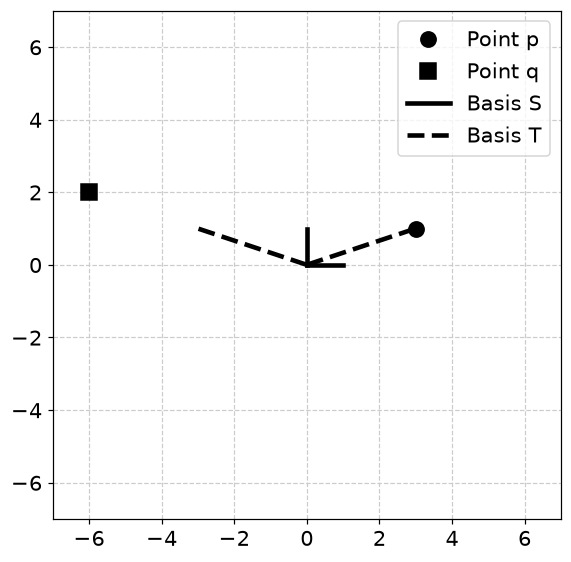

In [4]:
# points (in Cartesian coordinates)
p = (3,1)
q = (-6,2)

plt.figure(figsize=(6,6))

# draw points
plt.plot(p[0],p[1],'ko',markerfacecolor='k',markersize=10,label='Point p')
plt.plot(q[0],q[1],'ks',markerfacecolor='k',markersize=10,label='Point q')

# draw basis vectors
plt.plot([0,0],[0,1],'k',linewidth=3,label='Basis S')
plt.plot([0,1],[0,0],'k',linewidth=3)

plt.plot([0,3],[0,1],'k--',linewidth=3,label='Basis T')
plt.plot([0,-3],[0,1],'k--',linewidth=3)


plt.axis('square')
plt.grid(linestyle='--',color=[.8,.8,.8])
plt.xlim([-7,7])
plt.ylim([-7,7])
plt.legend()
plt.savefig(ASSET / 'Figure_02_04.png',dpi=140)
plt.show()

## 연습문제 1 · 반복문으로 선형결합

- **목표**: 벡터 가중합을 반복문과 직접 식으로 계산합니다.
- **풀이 순서**: 0벡터에서 시작해 `zip`으로 묶인 가중치와 벡터의 곱을 누적합니다.
- **결과 해석**: 결과는 $(-7,-4,-13)$입니다. 초기 배열이 float라 소수점이 붙어도 같은 값입니다.

### 코드 02-04

- 원본: `original_py/LA4DS_ch02.py` 55–69행.

In [5]:
## Note: Make sure you run the code earlier to create variables l1, l2, etc.

# organized into lists
scalars = [ l1,l2,l3 ]
vectors = [ v1,v2,v3 ]

# initialize the linear combination
linCombo = np.zeros(len(v1))

# implement linear weighted combination using zip()
for s,v in zip(scalars,vectors):
  linCombo += s*v

# confirm it's the same answer as above
linCombo

Out[5]: array([ -7.,  -4., -13.])


## 연습문제 2 · 목록 길이가 다른 경우

- **목표**: 암묵적 절단과 명시적 인덱스 오류를 비교합니다.
- **풀이 순서**: 가중치를 4개, 벡터를 3개로 두고 가중치 길이만큼 인덱싱합니다. 네 번째 벡터에서 오류를 확인합니다.
- **결과 해석**: `IndexError`가 예상 결과입니다. zip은 조용히 마지막 가중치를 무시하므로 계산 전에 두 길이가 같은지 검증하는 편이 안전합니다.

### 코드 02-05

- 원본: `original_py/LA4DS_ch02.py` 73–84행.
- **보완**: 의도된 오류를 해당 예외 타입으로 처리하고 오류 메시지를 출력합니다.

In [6]:
try:
    # Whether it works or throws an error depends on how you set up the code.
    # Using zip() as above works, because zip() will use only the minimum-matching items.
    # Re-writing the code using indexing will cause an error, as in the code below.

    # make the scalars longer
    scalars = [ l1,l2,l3,5 ]
    vectors = [ v1,v2,v3 ]

    linCombo = np.zeros(len(v1))

    for i in range(len(scalars)):
      linCombo += scalars[i]*vectors[i]
except IndexError as exc:
    print("학습용 예상 오류:", type(exc).__name__, str(exc))

학습용 예상 오류: IndexError list index out of range


## 연습문제 3 · 직선과 평면 생성하기

- **목표**: 벡터의 독립성이 생성공간 차원을 결정함을 봅니다.
- **풀이 순서**: 벡터 하나에 난수 스칼라를 곱해 직선을 그립니다. 다음으로 3차원 벡터 두 개의 난수 선형결합을 그립니다. 두 번째 벡터를 첫 번째의 절반으로 바꾸어 비교할 수 있습니다.
- **결과 해석**: 독립인 두 벡터는 평면, 서로 배수이면 직선입니다. 점의 개수가 많아져도 차원은 독립 방향의 개수로 결정됩니다.

### 코드 02-06

- 원본: `original_py/LA4DS_ch02.py` 88–117행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

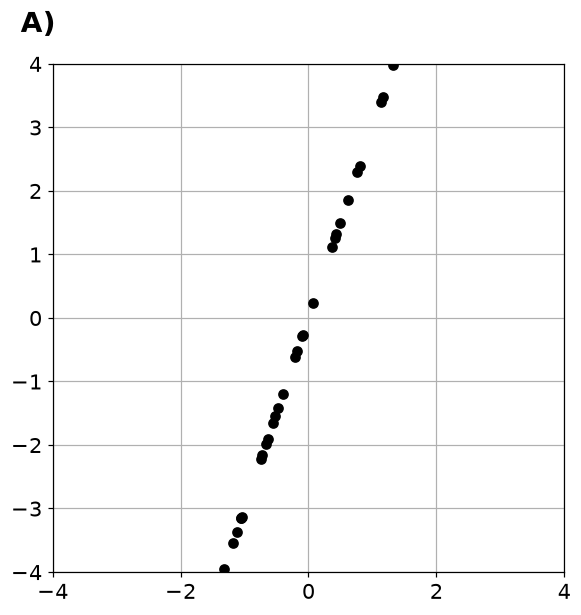

In [7]:
# the vector set (just one vector)
A  = np.array([ 1,3 ])

# x-axis range
xlim = [-4,4]

# random scalars in that range
scalars = np.random.uniform(low=xlim[0],high=xlim[1],size=100)



# create a figure, etc
plt.figure(figsize=(6,6))

# loop over the random scalars
for s in scalars:

  # create point p
  p = A*s

  # plot it
  plt.plot(p[0],p[1],'ko')


plt.xlim(xlim)
plt.ylim(xlim)
plt.grid()
plt.text(-4.5,4.5,'A)',fontweight='bold',fontsize=18)
plt.savefig(ASSET / 'Figure_02_07a.png',dpi=140)
plt.show()

### 코드 02-07

- 원본: `original_py/LA4DS_ch02.py` 119–149행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: Plotly 3차원 그림은 HTML로 보존하고, Markdown용 정적 3차원 산점도를 추가했습니다.

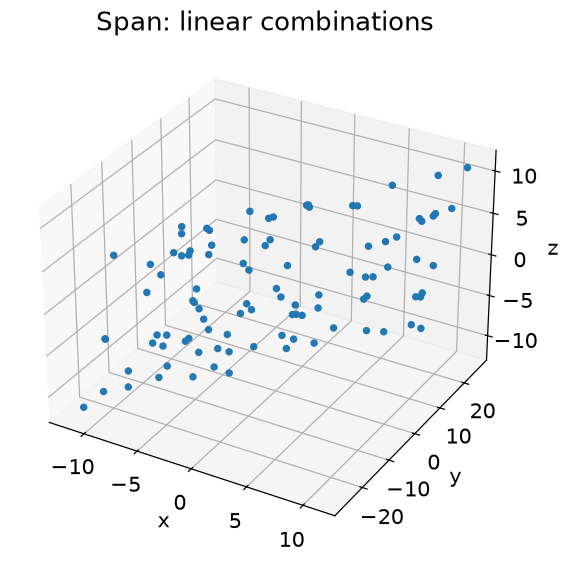

In [8]:
import plotly.graph_objects as go

# two vectors in R3
v1 = np.array([ 3,5,1 ])
v2 = np.array([ 0,2,2 ])

## uncomment the lines below for the second part
# v1 = np.array([ 3.0,5.0,1.0 ])
# v2 = np.array([ 1.5,2.5,0.5 ])


# random scalars in the x-axis range
scalars = np.random.uniform(low=xlim[0],high=xlim[1],size=(100,2))



# create random points
points = np.zeros((100,3))
for i in range(len(scalars)):

  # define this point as a random weighted combination of the two vectors
  points[i,:] = v1*scalars[i,0] + v2*scalars[i,1]


# draw the dots in the plane
fig = go.Figure( data=[go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], 
                                    mode='markers', marker=dict(size=6,color='black') )])

fig.update_layout(margin=dict(l=0,r=0,b=0,t=0))
plt.savefig(ASSET / 'Figure_02_07b.png',dpi=140)
fig.write_html(str(ASSET / 'interactive_3d.html'), include_plotlyjs=True)
ax = plt.figure(figsize=(7, 6)).add_subplot(projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], s=15)
ax.set(xlabel='x', ylabel='y', zlabel='z', title='Span: linear combinations')
plt.show()

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [9]:
_B=np.array([[3.,-3.],[1.,1.]])
for _p in [np.array([3.,1.]),np.array([-6.,2.])]:
    _coord=np.linalg.solve(_B,_p)
    print('점:',_p,'새 좌표:',_coord)
    assert np.allclose(_B@_coord,_p)
print('기저 행렬의 랭크:',np.linalg.matrix_rank(_B))


점: [3. 1.] 새 좌표: [1. 0.]
점: [-6.  2.] 새 좌표: [0. 2.]
기저 행렬의 랭크: 2
